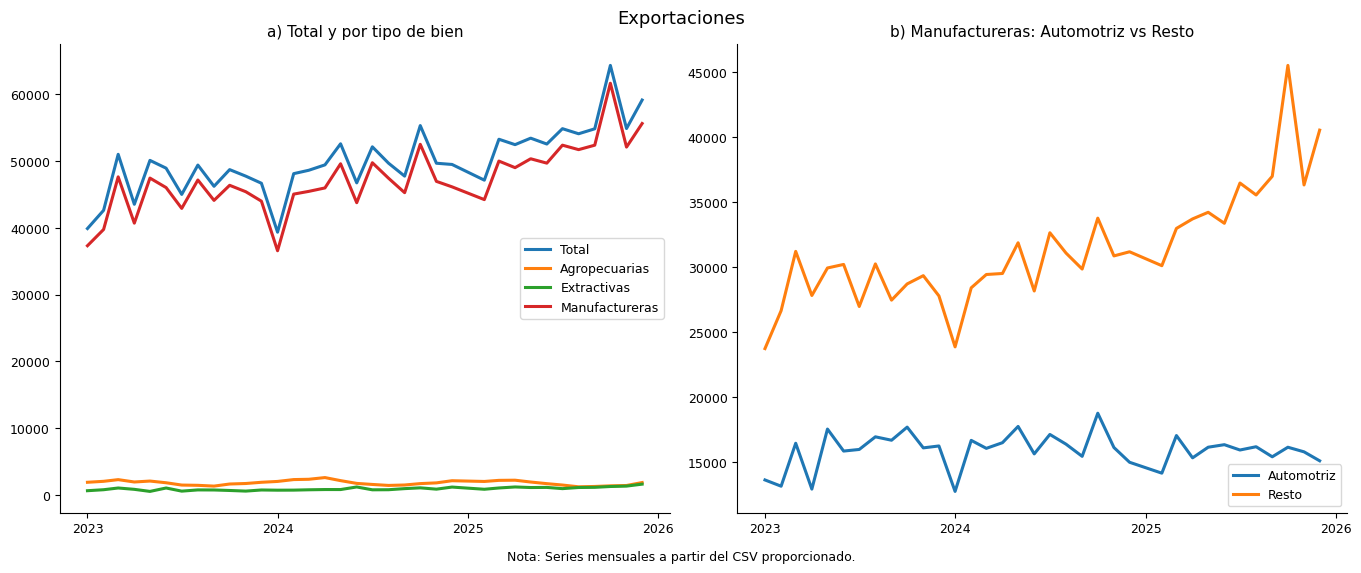

In [2]:
import csv
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================
# CONFIG
# ============================================================
PATH = "raw/exp_no_pet.csv"     # <-- ajusta
TITLE = "Exportaciones"
SAVE_PATH = "fig_exportaciones.png"  # opcional

MONTHS = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4, "mayo": 5, "junio": 6,
    "julio": 7, "agosto": 8, "septiembre": 9, "setiembre": 9, "octubre": 10,
    "noviembre": 11, "diciembre": 12,
}

def _to_float(x):
    if x is None:
        return np.nan
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan
    # si algún día vinieran separadores de miles
    s = s.replace(",", "")
    try:
        return float(s)
    except:
        return np.nan

def read_exp_no_pet_csv(path: str) -> pd.DataFrame:
    """
    Lee el CSV como viene:
      - encabezado 1: Periodo,Total,Agropecuarias,Extractivas,Manufactureras
      - encabezado 2: Total,Automotriz,Resto   (solo para la descomposición)
      - filas de año: 2023, 2024, ...
      - filas de mes: Enero, ..., con 7 campos
    """
    rows = []
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f)
        for r in reader:
            # quita espacios
            r = [c.strip() for c in r]
            if len(r) == 0 or (len(r) == 1 and r[0] == ""):
                continue
            rows.append(r)

    # Saltamos las 2 filas de encabezado
    data = rows[2:]

    current_year = None
    out = []

    for r in data:
        # r puede venir de longitud 1 (año) o 7 (mes+valores)
        first = r[0].strip()

        # año
        if re.fullmatch(r"\d{4}", first):
            current_year = int(first)
            continue

        # mes
        mkey = first.lower()
        if mkey not in MONTHS or current_year is None:
            continue

        # Asegura longitud 7 (Periodo + 6 valores)
        # Formato esperado:
        # Mes, Total, Agro, Extract, Manuf_total, Automotriz, Resto
        r = (r + [""] * 7)[:7]

        dt = pd.Timestamp(current_year, MONTHS[mkey], 1)

        out.append({
            "date": dt,
            "Total": _to_float(r[1]),
            "Agropecuarias": _to_float(r[2]),
            "Extractivas": _to_float(r[3]),
            "Manufacturas": _to_float(r[4]),
            "Automotriz": _to_float(r[5]),
            "Resto": _to_float(r[6]),
        })

    df = pd.DataFrame(out).sort_values("date").reset_index(drop=True)
    return df

df = read_exp_no_pet_csv(PATH)

# ============================================================
# PLOT (2 paneles)
# ============================================================
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.2), constrained_layout=True)

def style_axes(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# ---- Panel 1
ax1.plot(df["date"], df["Total"], linewidth=2.2, label="Total")
ax1.plot(df["date"], df["Agropecuarias"], linewidth=2.2, label="Agropecuarias")
ax1.plot(df["date"], df["Extractivas"], linewidth=2.2, label="Extractivas")
ax1.plot(df["date"], df["Manufacturas"], linewidth=2.2, label="Manufactureras")

ax1.set_title("a) Total y por tipo de bien")
style_axes(ax1)
ax1.legend(loc="center right", frameon=True, framealpha=0.75, fontsize=9)

# ---- Panel 2 (Automotriz vs Resto)
# Usa 2 ejes SOLO si la escala es muy distinta
yA = df["Automotriz"].dropna()
yR = df["Resto"].dropna()

use_two_axes = False
if len(yA) >= 6 and len(yR) >= 6:
    medA = np.nanmedian(yA)
    medR = np.nanmedian(yR)
    if medA > 0 and medR > 0:
        ratio = medR / medA
        use_two_axes = (ratio > 2.2) or (ratio < (1/2.2))

ax2.set_title("b) Manufactureras: Automotriz vs Resto")
style_axes(ax2)

if use_two_axes:
    ax2b = ax2.twinx()
    ax2b.spines["top"].set_visible(False)
    ax2b.tick_params(axis="y", labelsize=9)

    l1, = ax2.plot(df["date"], df["Automotriz"], linewidth=2.2, label="Automotriz")
    l2, = ax2b.plot(df["date"], df["Resto"], linewidth=2.2, label="Resto")

    ax2.legend([l1, l2], ["Automotriz", "Resto"],
               loc="lower right", frameon=True, framealpha=0.75, fontsize=9)
else:
    ax2.plot(df["date"], df["Automotriz"], linewidth=2.2, label="Automotriz")
    ax2.plot(df["date"], df["Resto"], linewidth=2.2, label="Resto")
    ax2.legend(loc="lower right", frameon=True, framealpha=0.75, fontsize=9)

fig.suptitle(TITLE, y=1.02, fontsize=13)


fig.text(
    0.5, -0.02,
    "Nota: Series mensuales a partir del CSV proporcionado.",
    ha="center", va="top", fontsize=9
)

plt.show()



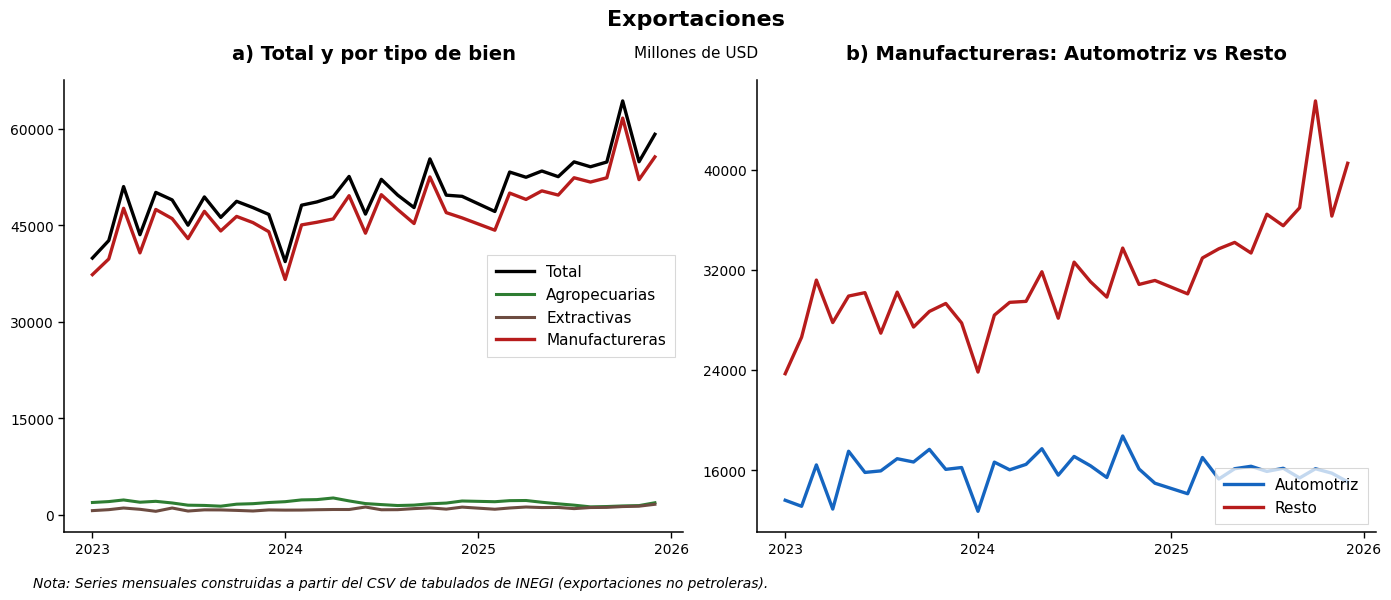

In [5]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

# ============================================================
# CONFIG
# ============================================================
PATH = "raw/exp_no_pet.csv"      # <-- ajusta si tu ruta es distinta
TITLE_MAIN = "Exportaciones"
SUBTITLE = "Millones de USD"
SAVE_PATH = "fig_exportaciones_formal.png"

MONTHS = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4, "mayo": 5, "junio": 6,
    "julio": 7, "agosto": 8, "septiembre": 9, "setiembre": 9, "octubre": 10,
    "noviembre": 11, "diciembre": 12,
}

def _to_float(x):
    if x is None:
        return np.nan
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan
    # tolerante a separadores
    s = s.replace(",", "")
    try:
        return float(s)
    except:
        return np.nan

def read_exp_no_pet_csv(path: str) -> pd.DataFrame:
    """
    Lee el CSV como el de tabulados INEGI:
      - 2 renglones de encabezaimport csv
import re
import numpy as npdo
      - filas de año: 2023, 2024, ...
      - filas de mes: Enero,... con campos:
        Mes, Total, Agropecuarias, Extractivas, Manufacturas_total, Automotriz, Resto
    """
    rows = []
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f)
        for r in reader:
            r = [c.strip() for c in r]
            if len(r) == 0 or (len(r) == 1 and r[0] == ""):
                continue
            rows.append(r)

    if len(rows) < 3:
        raise ValueError("El archivo no tiene suficientes filas (¿está vacío o mal descargado?).")

    data = rows[2:]  # saltar encabezados
    current_year = None
    out = []

    for r in data:
        first = r[0].strip()

        # año
        if re.fullmatch(r"\d{4}", first):
            current_year = int(first)
            continue

        # mes
        mkey = first.lower()
        if mkey not in MONTHS or current_year is None:
            continue

        # asegurar longitud 7: [Mes, Total, Agro, Extract, Manuf, Auto, Resto]
        r = (r + [""] * 7)[:7]
        dt = pd.Timestamp(current_year, MONTHS[mkey], 1)

        out.append({
            "date": dt,
            "Total": _to_float(r[1]),
            "Agropecuarias": _to_float(r[2]),
            "Extractivas": _to_float(r[3]),
            "Manufacturas": _to_float(r[4]),
            "Automotriz": _to_float(r[5]),
            "Resto": _to_float(r[6]),
        })

    df = pd.DataFrame(out).sort_values("date").reset_index(drop=True)

    # valida que haya algo
    if df.empty:
        raise ValueError(
            "No pude construir la serie. Revisa que el CSV tenga filas con año (YYYY) "
            "y meses en español (Enero, Febrero, ...)."
        )

    return df

def banxico_style(ax):
    """Estilo formal tipo Banxico (lo que aplica): limpio, sin rejilla, spines sobrios."""
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)

    ax.tick_params(axis="both", which="major", labelsize=10, width=1.0, length=4, direction="out")
    ax.tick_params(axis="both", which="minor", width=0.8, length=2.5, direction="out")

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

def maybe_two_axes(df, col_left="Automotriz", col_right="Resto", threshold=2.2):
    """Decide 2 ejes solo si las escalas difieren mucho (robusto)."""
    yL = df[col_left].dropna()
    yR = df[col_right].dropna()
    if len(yL) < 6 or len(yR) < 6:
        return False
    medL = np.nanmedian(yL)
    medR = np.nanmedian(yR)
    if not np.isfinite(medL) or not np.isfinite(medR) or medL <= 0 or medR <= 0:
        return False
    ratio = medR / medL
    return (ratio > threshold) or (ratio < 1/threshold)

# ============================================================
# 1) LEER
# ============================================================
df = read_exp_no_pet_csv(PATH)

# ============================================================
# 2) COLORES (sobrios)
# ============================================================
C_TOTAL = "#000000"
C_AGRO  = "#2E7D32"
C_EXT   = "#6D4C41"
C_MANUF = "#B71C1C"

C_AUTO  = "#1565C0"
C_RESTO = "#B71C1C"

# ============================================================
# 3) FIGURA
# ============================================================
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.8, 5.2), constrained_layout=True)

# --- Panel (a): 4 líneas
ax1.plot(df["date"], df["Total"],         lw=2.4, color=C_TOTAL, label="Total")
ax1.plot(df["date"], df["Agropecuarias"], lw=2.2, color=C_AGRO,  label="Agropecuarias")
ax1.plot(df["date"], df["Extractivas"],   lw=2.2, color=C_EXT,   label="Extractivas")
ax1.plot(df["date"], df["Manufacturas"],  lw=2.4, color=C_MANUF, label="Manufactureras")

ax1.set_title("a) Total y por tipo de bien", fontsize=14, fontweight="bold", pad=15)
banxico_style(ax1)

leg1 = ax1.legend(
    loc="center right",
    frameon=True,
    fancybox=False,
    framealpha=.75,
    borderpad=0.6,
    handlelength=2.5,
    handletextpad=0.8,
    columnspacing=1.2)
leg1.get_frame().set_linewidth(0.8)

# --- Panel (b): Automotriz vs Resto (2 ejes solo si hace falta)
ax2.set_title("b) Manufactureras: Automotriz vs Resto", fontsize=14, fontweight="bold", pad=15)
banxico_style(ax2)

use_two_axes = maybe_two_axes(df, "Automotriz", "Resto", threshold=2.2)

if use_two_axes:
    ax2b = ax2.twinx()
    ax2b.grid(False)
    ax2b.spines["top"].set_visible(False)
    ax2b.spines["right"].set_linewidth(1.1)
    ax2b.tick_params(axis="y", which="major", labelsize=10, width=1.0, length=4, direction="out")

    l1, = ax2.plot(df["date"], df["Automotriz"], lw=2.4, color=C_AUTO,  label="Automotriz")
    l2, = ax2b.plot(df["date"], df["Resto"],     lw=2.4, color=C_RESTO, label="Resto")

    leg2 = ax2.legend([l1, l2], ["Automotriz", "Resto"],
                      loc="lower right", frameon=True, framealpha=0.75,
                      fontsize=10, borderpad=0.6, handlelength=2.6)
    leg2.get_frame().set_linewidth(0.8)
else:
    ax2.plot(df["date"], df["Automotriz"], lw=2.4, color=C_AUTO,  label="Automotriz")
    ax2.plot(df["date"], df["Resto"],     lw=2.4, color=C_RESTO, label="Resto")

    leg2 = ax2.legend(
        loc="lower right",
        frameon=True,
        fancybox=False,
        framealpha=.75,
        borderpad=0.6,
        handlelength=2.5,
        handletextpad=0.8,
        columnspacing=1.2)

    leg2.get_frame().set_linewidth(0.8)

# --- Título general + nota
fig.suptitle(TITLE_MAIN, y=1.06,fontsize=16, fontweight="bold")
fig.text(0.5, 0.99, SUBTITLE, ha="center", va="top", fontsize=11)

fig.text(
    0.02, -0.03,
    "Nota: Series mensuales construidas a partir del CSV de tabulados de INEGI (exportaciones no petroleras).",
    ha="left", va="top", fontsize=10, style="italic")

plt.show()



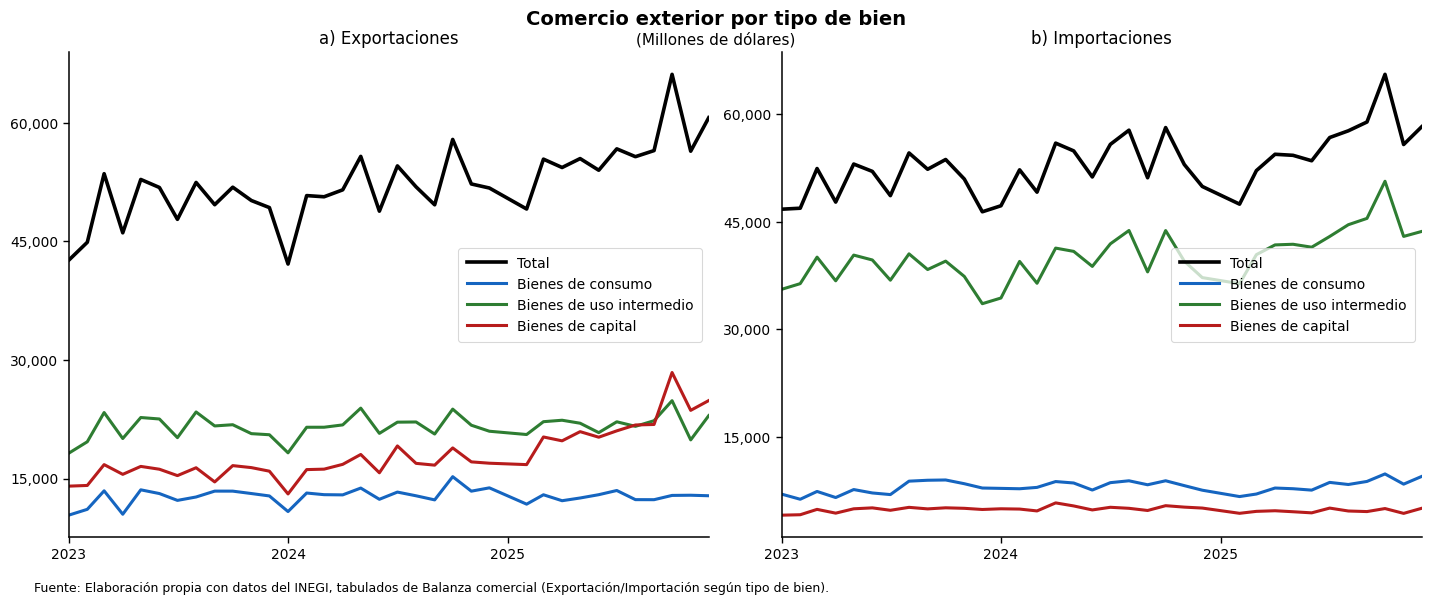

In [15]:
import csv
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator, FuncFormatter

# ============================================================
# CONFIG
# ============================================================
PATH_EXP = "raw/exp_tipo_bien.csv"
PATH_IMP = "raw/imp_tipo_bien.csv"

TITLE_MAIN = "Comercio exterior por tipo de bien"
SUBTITLE = "(Millones de dólares)"
SAVE_PATH = "fig_exp_imp_tipo_bien.png"

MONTHS = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4, "mayo": 5, "junio": 6,
    "julio": 7, "agosto": 8, "septiembre": 9, "setiembre": 9, "octubre": 10,
    "noviembre": 11, "diciembre": 12,
}

# ============================================================
# LECTURA ROBUSTA (tabulados INEGI)
# Espera filas:
#   2023
#   Enero, 42609.7, 10368.6, 18200.5, 14040.6
# columnas: Total, Bienes de consumo, Bienes de uso intermedio, Bienes de capital
# ============================================================

def _to_float(x):
    if x is None:
        return np.nan
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan
    s = s.replace(",", "")  # por si algún día viniera con separador de miles
    try:
        return float(s)
    except:
        return np.nan

def read_tipo_bien_csv(path: str) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f)
        for r in reader:
            r = [c.strip() for c in r]
            if len(r) == 0 or (len(r) == 1 and r[0] == ""):
                continue
            rows.append(r)

    if len(rows) < 3:
        raise ValueError(f"Archivo muy corto o vacío: {path}")

    # en tabulados INEGI suele haber 1–2 filas de encabezado
    # estrategia: avanzar hasta encontrar una fila que sea año (YYYY)
    start = None
    for i, r in enumerate(rows[:20]):
        if len(r) and re.fullmatch(r"\d{4}", r[0].strip()):
            start = i
            break
    if start is None:
        raise ValueError(
            f"No encontré el primer año (YYYY) en las primeras filas de: {path}. "
            "Revisa que sea el CSV descargado de tabulados."
        )

    data = rows[start:]
    current_year = None
    out = []

    for r in data:
        first = r[0].strip()

        # año
        if re.fullmatch(r"\d{4}", first):
            current_year = int(first)
            continue

        mkey = first.lower()
        if mkey not in MONTHS or current_year is None:
            continue

        # esperamos: Mes + 4 números
        r = (r + [""] * 5)[:5]
        dt = pd.Timestamp(current_year, MONTHS[mkey], 1)

        out.append({
            "date": dt,
            "Total": _to_float(r[1]),
            "Consumo": _to_float(r[2]),
            "Intermedios": _to_float(r[3]),
            "Capital": _to_float(r[4]),
        })

    df = pd.DataFrame(out).sort_values("date").reset_index(drop=True)
    if df.empty:
        raise ValueError(f"No pude parsear datos (meses/años) desde: {path}")
    return df

# ============================================================
# ESTILO BANXICO (lo que aplica)
# ============================================================
def banxico_style(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)
    ax.tick_params(axis="both", which="major", labelsize=10, width=1.0, length=4, direction="out")
    ax.tick_params(axis="both", which="minor", width=0.8, length=2.5, direction="out")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

def comma_thousands(x, pos):
    # 50,000 estilo formal (sin decimales)
    if not np.isfinite(x):
        return ""
    return f"{x:,.0f}"

# Paleta sobria (Banxico-ish)
C_TOTAL = "#000000"
C_CONS  = "#1565C0"  # azul
C_INT   = "#2E7D32"  # verde
C_CAP   = "#B71C1C"  # rojo

# ============================================================
# CARGA
# ============================================================
exp = read_tipo_bien_csv(PATH_EXP)
imp = read_tipo_bien_csv(PATH_IMP)

# asegurar mismo rango temporal en la figura (opcional)
start = min(exp["date"].min(), imp["date"].min())
end   = max(exp["date"].max(), imp["date"].max())

# ============================================================
# PLOT
# ============================================================
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.2, 5.4), constrained_layout=True)

# ---- Panel (a) Exportaciones
ax1.plot(exp["date"], exp["Total"],       lw=2.6, color=C_TOTAL, label="Total")
ax1.plot(exp["date"], exp["Consumo"],     lw=2.2, color=C_CONS,  label="Bienes de consumo")
ax1.plot(exp["date"], exp["Intermedios"], lw=2.2, color=C_INT,   label="Bienes de uso intermedio")
ax1.plot(exp["date"], exp["Capital"],     lw=2.2, color=C_CAP,   label="Bienes de capital")

ax1.set_title("a) Exportaciones")
banxico_style(ax1)
ax1.set_xlim(start, end)
ax1.yaxis.set_major_formatter(FuncFormatter(comma_thousands))

leg1 = ax1.legend(
    loc="center right",
    frameon=True,
    framealpha=0.75,
    fontsize=10,
    borderpad=0.6,
    handlelength=2.8
)
leg1.get_frame().set_linewidth(0.8)

# ---- Panel (b) Importaciones
ax2.plot(imp["date"], imp["Total"],       lw=2.6, color=C_TOTAL, label="Total")
ax2.plot(imp["date"], imp["Consumo"],     lw=2.2, color=C_CONS,  label="Bienes de consumo")
ax2.plot(imp["date"], imp["Intermedios"], lw=2.2, color=C_INT,   label="Bienes de uso intermedio")
ax2.plot(imp["date"], imp["Capital"],     lw=2.2, color=C_CAP,   label="Bienes de capital")

ax2.set_title("b) Importaciones")
banxico_style(ax2)
ax2.set_xlim(start, end)
ax2.yaxis.set_major_formatter(FuncFormatter(comma_thousands))

leg2 = ax2.legend(
    loc="center right",
    frameon=True,
    framealpha=0.75,
    fontsize=10,
    borderpad=0.6,
    handlelength=2.8
)
leg2.get_frame().set_linewidth(0.8)

# ---- Títulos arriba (formal)
fig.suptitle(TITLE_MAIN, y=1.03, fontsize=14, fontweight="bold")
fig.text(0.5, 0.99, SUBTITLE, ha="center", va="top", fontsize=11)

# ---- Nota al pie
fig.text(
    0.02, -0.03,
    "Fuente: Elaboración propia con datos del INEGI, tabulados de Balanza comercial (Exportación/Importación según tipo de bien).",
    ha="left", va="top", fontsize=9
)

plt.show()




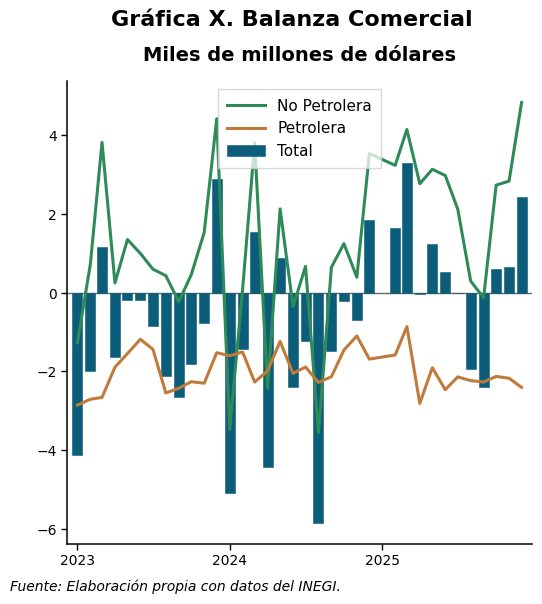

In [16]:
import csv
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

# ============================================================
# CONFIG
# ============================================================
PATH_CSV = "raw/BC_p.csv"   # <-- tu archivo (el que descargaste de INEGI)
TITLE = "Gráfica X. Balanza Comercial"
YLABEL = "Miles de millones de dólares"  # <-- como en tu figura

# Colores (muy parecidos al ejemplo)
C_TOTAL = "#0B5D7A"   # barra azul/teal
C_NOPET = "#2E8B57"   # verde
C_PET   = "#C07A3A"   # naranja/café
C_ZERO  = "#666666"   # línea cero

MONTHS = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4, "mayo": 5, "junio": 6,
    "julio": 7, "agosto": 8, "septiembre": 9, "setiembre": 9, "octubre": 10,
    "noviembre": 11, "diciembre": 12,
}

def _to_float(x):
    if x is None:
        return np.nan
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan
    s = s.replace(",", "")
    try:
        return float(s)
    except:
        return np.nan

def read_inegi_bc_csv(path: str) -> pd.DataFrame:
    """
    Lee CSV de INEGI tipo tabulado como el tuyo:
      - Fila 1: encabezado general
      - Fila 2: subencabezados
      - Luego: una línea con año (YYYY)
      - Luego: líneas mensuales con 6 valores:
        Mes, Exp_pet, Exp_nopet, Imp_pet, Imp_nopet, Saldo_pet, Saldo_nopet
    """
    rows = []
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f)
        for r in reader:
            r = [c.strip() for c in r]
            if len(r) == 0 or (len(r) == 1 and r[0] == ""):
                continue
            rows.append(r)

    if len(rows) < 4:
        raise ValueError("El CSV no tiene suficientes filas (¿se descargó bien?).")

    data = rows[2:]  # saltar 2 filas de encabezados
    current_year = None
    out = []

    for r in data:
        first = (r[0] if len(r) else "").strip()

        # línea con año
        if re.fullmatch(r"\d{4}", first):
            current_year = int(first)
            continue

        # línea con mes
        mkey = first.lower()
        if current_year is None or mkey not in MONTHS:
            continue

        # tu formato trae: Mes + 6 números
        r = (r + [""] * 7)[:7]  # [Mes, v1, v2, v3, v4, v5, v6]
        dt = pd.Timestamp(current_year, MONTHS[mkey], 1)

        out.append({
            "date": dt,
            "saldo_pet_musd":   _to_float(r[5]),
            "saldo_nopet_musd": _to_float(r[6]),
        })

    df = pd.DataFrame(out).sort_values("date").reset_index(drop=True)

    if df.empty:
        raise ValueError("No pude construir la serie: revisa que haya años (YYYY) y meses en español.")

    # Total = petrolera + no petrolera
    df["saldo_total_musd"] = df["saldo_pet_musd"] + df["saldo_nopet_musd"]

    # Convertir de MILLONES de USD a MILES DE MILLONES (billions) => /1000
    df["saldo_pet_busd"]   = df["saldo_pet_musd"] / 1000.0
    df["saldo_nopet_busd"] = df["saldo_nopet_musd"] / 1000.0
    df["saldo_total_busd"] = df["saldo_total_musd"] / 1000.0

    return df

def banxico_like(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)

    ax.tick_params(axis="both", which="major", labelsize=10, width=1.0, length=4, direction="out")
    ax.tick_params(axis="both", which="minor", width=0.8, length=2.5, direction="out")

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=7))

# ============================================================
# 1) LEER + ARMAR SERIES
# ============================================================
df = read_inegi_bc_csv(PATH_CSV)

# ============================================================
# 2) GRAFICAR (formato como tu ejemplo)
# ============================================================
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

fig, ax = fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Barras: Total
bar_width_days = 24  # ancho visual para mensual
ax.bar(
    df["date"], df["saldo_total_busd"],
    width=bar_width_days,
    color=C_TOTAL,
    edgecolor=C_TOTAL,
    linewidth=0.4,
    label="Total",
    zorder=2
)

# Líneas: No petrolera y Petrolera
ax.plot(df["date"], df["saldo_nopet_busd"], color=C_NOPET, lw=2.2, label="No Petrolera", zorder=3)
ax.plot(df["date"], df["saldo_pet_busd"],   color=C_PET,   lw=2.2, label="Petrolera",   zorder=3)

# Línea cero
ax.axhline(0, color=C_ZERO, lw=1.0, zorder=1)

# Título (como en la figura: título + subtítulo)
ax.set_title(f"{YLABEL}", fontsize=14, fontweight="bold", pad=15)

# Estilo + ejes
banxico_like(ax)
ax.set_ylabel("")  # en la figura el texto va en el subtítulo, no como label vertical

# Rango x compacto (opcional, se ve similar a INEGI)
ax.set_xlim(df["date"].min() - pd.Timedelta(days=25), df["date"].max() + pd.Timedelta(days=25))

# Leyenda arriba centrada (como el ejemplo)
leg = ax.legend(
    loc="upper center",
    frameon=True,
    fancybox=False,
    framealpha=.75,
    borderpad=0.6,
    handlelength=2.5,
    handletextpad=0.8,
    columnspacing=1.2
)
fig.suptitle(
    TITLE,
    fontsize=16, fontweight="bold", y = 1
)

fig.text(
    0.03, 0.05,
    "Fuente: Elaboración propia con datos del INEGI.",
    ha="left", va="top", fontsize=10, style="italic"
)
plt.show()


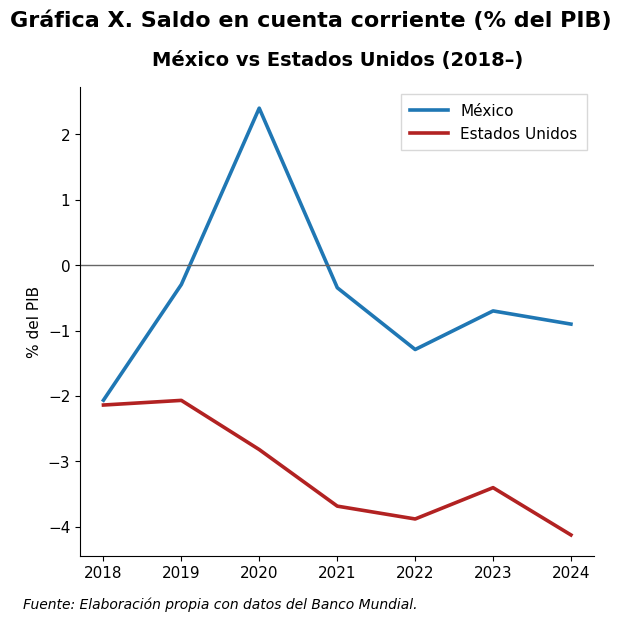

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================
# CONFIG
# ============================================================
PATH = "raw/cc.csv"   # o "raw/cc.csv"
START_YEAR = 2018

COLOR_MX = "#1f77b4"   # azul
COLOR_US = "#b22222"   # rojo oscuro

# ============================================================
# 1) LEER (WDI: saltar 4 filas de metadata)
# ============================================================
df = pd.read_csv(PATH, skiprows=4, encoding="utf-8-sig")

# Normaliza nombres
df.columns = [c.strip() for c in df.columns]

# Identifica columnas base + años
base_cols = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"]
year_cols = [c for c in df.columns if c.isdigit()]  # "1960", "1961", ...

# Filtra México y USA
keep = df[df["Country Code"].isin(["MEX", "USA"])].copy()
if keep.empty:
    raise ValueError("No encontré Country Code MEX o USA en el archivo.")

# (Opcional) valida que sea el indicador esperado
# print(keep["Indicator Name"].unique())

# ============================================================
# 2) WIDE -> LONG
# ============================================================
long = keep.melt(
    id_vars=base_cols,
    value_vars=year_cols,
    var_name="year",
    value_name="value"
)

long["year"] = long["year"].astype(int)
long["value"] = pd.to_numeric(long["value"], errors="coerce")

# Filtra 2018+
long = long[long["year"] >= START_YEAR].copy()

# Crea fecha (anual)
long["date"] = pd.to_datetime(long["year"].astype(str) + "-01-01")

# ============================================================
# 3) SEPARA SERIES
# ============================================================
mx = long[long["Country Code"] == "MEX"].sort_values("date")
us = long[long["Country Code"] == "USA"].sort_values("date")

# ============================================================
# 4) GRAFICAR
# ============================================================
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ax.plot(mx["date"], mx["value"], lw=2.6, color=COLOR_MX, label="México")
ax.plot(us["date"], us["value"], lw=2.6, color=COLOR_US, label="Estados Unidos")

ax.axhline(0, color="#666666", lw=1.0)

ax.set_title("México vs Estados Unidos (2018–)", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("% del PIB")
ax.set_xlabel("")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# estilo limpio
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

ax.legend(
    loc="upper right",
    frameon=True,
    fancybox=False,
    framealpha=.75,
    borderpad=0.6,
    handlelength=2.5,
    handletextpad=0.8,
    columnspacing=1.2)
fig.suptitle(
    "Gráfica X. Saldo en cuenta corriente (% del PIB)",
    fontsize=16, fontweight="bold", y = .98
)
fig.text(
    0.02, 0.0,
    "Fuente: Elaboración propia con datos del Banco Mundial.",
    ha="left", va="top", fontsize=10, style="italic"
)
plt.tight_layout()
plt.show()
